In [1]:
pip install qiskit qiskit-machine-learning scikit-learn matplotlib numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 41.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.1/263.1 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 52.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 2.5 MB/s eta 0:00:00


In [2]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.svm import SVR

from qiskit.circuit.library import zz_feature_map
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit_machine_learning.algorithms import QSVR


X shape = (100, 2)
y shape = (100,)


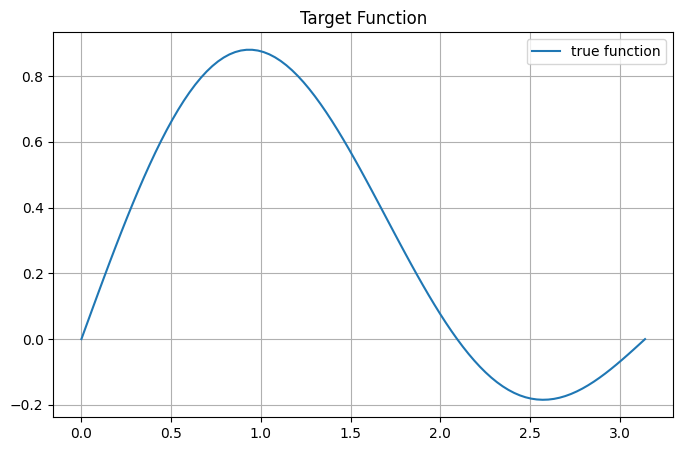

In [3]:

# =========================================================
# 1. 產生 1D 原始資料，再手動升成 2D 特徵
# =========================================================
num_of_data = 100

x = np.linspace(0 , np.pi, num_of_data)
x_raw = x.reshape(-1, 1)

# 更複雜的函數
y = (np.sin(x) + np.sin(2 * x)) / 2
X = np.hstack([x_raw, x_raw**2])

print("X shape =", X.shape)   # (1000, 2)
print("y shape =", y.shape)
plt.figure(figsize=(8, 5))
plt.plot(x, y, label="true function")
plt.title("Target Function")
plt.legend()
plt.grid(True)
plt.show()


In [4]:
# =========================================================
# 2. 切分資料
# =========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)


In [5]:
# =========================================================
# 3. 標準化
# =========================================================
x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train_scaled = x_scaler.fit_transform(X_train)
X_test_scaled = x_scaler.transform(X_test)

y_train_scaled = y_scaler.fit_transform(y_train.reshape(-1, 1)).ravel()



In [6]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector

def build_hea_feature_map(n_qubits, reps=1, entanglement="linear"):
    """
    建立 HEA-style feature map
    - 資料會以參數 x[i] 的形式進入旋轉閘
    - 每層包含：
        1. 單量子位資料編碼
        2. 糾纏層
    """
    x = ParameterVector("x", n_qubits)
    qc = QuantumCircuit(n_qubits)

    for _ in range(reps):
        # data encoding layer
        for i in range(n_qubits):
            qc.ry(x[i], i)
            qc.rz(x[i], i)

        # entanglement layer
        if entanglement == "linear":
            for i in range(n_qubits - 1):
                qc.cx(i, i + 1)
        elif entanglement == "circular":
            for i in range(n_qubits - 1):
                qc.cx(i, i + 1)
            if n_qubits > 2:
                qc.cx(n_qubits - 1, 0)
        elif entanglement == "full":
            for i in range(n_qubits):
                for j in range(i + 1, n_qubits):
                    qc.cx(i, j)
        else:
            raise ValueError("entanglement must be 'linear', 'circular', or 'full'")

    return qc

In [7]:
# =========================================================
# 4. 建立 2-qubit HEA feature map
# =========================================================
feature_map = build_hea_feature_map(
    n_qubits=2,
    reps=10,
    entanglement="linear"
)

# Quantum kernel
qkernel = FidelityQuantumKernel(feature_map=feature_map)



In [8]:
# =========================================================
# 5. 建立並訓練 QSVR
# =========================================================
qsvr = QSVR(
    quantum_kernel=qkernel,
    C=10.0,
    epsilon=0.1
)

qsvr.fit(X_train_scaled, y_train_scaled)

QSVR(C=10.0, cache_size=200, coef0=0.0, degree=3, epsilon=0.1, gamma='scale',
     max_iter=-1,
     quantum_kernel=<qiskit_machine_learning.kernels.fidelity_quantum_kernel.FidelityQuantumKernel object at 0x7ec8b7852690>,
     shrinking=True, tol=0.001, verbose=False)

In [9]:
# =========================================================
# 6. 預測
# =========================================================
y_pred_scaled = qsvr.predict(X_test_scaled)
y_pred = y_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()



In [10]:
# =========================================================
# 7. 傳統 SVR 當對照組
# =========================================================
svr = SVR(kernel="rbf", C=10.0, epsilon=0.1, gamma="scale")
svr.fit(X_train_scaled, y_train_scaled)

y_pred_svr_scaled = svr.predict(X_test_scaled)
y_pred_svr = y_scaler.inverse_transform(y_pred_svr_scaled.reshape(-1, 1)).ravel()



In [11]:
# =========================================================
# 8. 評估
# =========================================================
print("===== QSVR =====")
print("MSE =", mean_squared_error(y_test, y_pred))
print("R2  =", r2_score(y_test, y_pred))

print("\n===== Classical SVR =====")
print("MSE =", mean_squared_error(y_test, y_pred_svr))
print("R2  =", r2_score(y_test, y_pred_svr))



===== QSVR =====
MSE = 0.069722363724155
R2  = 0.5957309389725569

===== Classical SVR =====
MSE = 0.0010016242122161876
R2  = 0.9941923127939694


In [12]:
# =========================================================
# 9. 畫平滑曲線
#    注意：因為模型吃的是 2 維特徵，所以畫圖時也要做相同升維
# =========================================================
x_plot_raw = np.linspace(0, 2 * np.pi, 300).reshape(-1, 1)
X_plot = np.hstack([x_plot_raw, x_plot_raw**2])
X_plot_scaled = x_scaler.transform(X_plot)

y_plot_qsvr_scaled = qsvr.predict(X_plot_scaled)
y_plot_qsvr = y_scaler.inverse_transform(y_plot_qsvr_scaled.reshape(-1, 1)).ravel()

y_plot_svr_scaled = svr.predict(X_plot_scaled)
y_plot_svr = y_scaler.inverse_transform(y_plot_svr_scaled.reshape(-1, 1)).ravel()



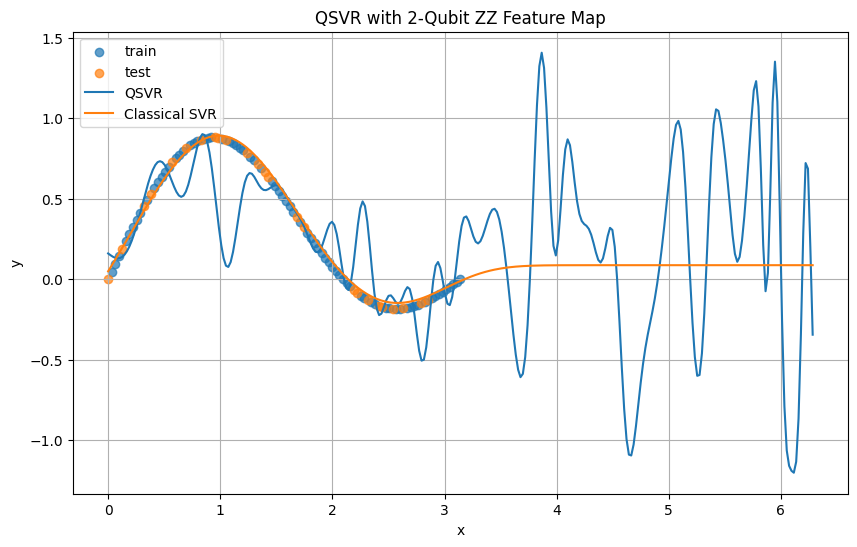

In [13]:
# =========================================================
# 10. 畫圖
# =========================================================
plt.figure(figsize=(10, 6))

# 這裡橫軸還是用原本的一維 x_raw 來畫，方便看 sin 曲線
plt.scatter(X_train[:, 0], y_train, label="train", alpha=0.7)
plt.scatter(X_test[:, 0], y_test, label="test", alpha=0.7)


plt.plot(x_plot_raw, y_plot_qsvr, label="QSVR")
plt.plot(x_plot_raw, y_plot_svr, label="Classical SVR")

plt.title("QSVR with 2-Qubit ZZ Feature Map")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()


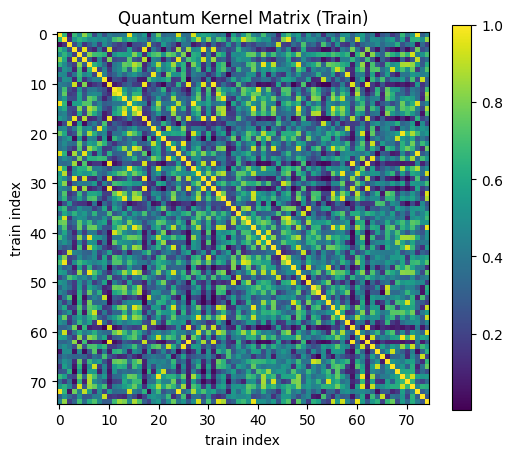

In [14]:
# =========================================================
# 11. 畫 quantum kernel matrix
# =========================================================
K_train = qkernel.evaluate(X_train_scaled)

plt.figure(figsize=(6, 5))
plt.imshow(K_train)
plt.colorbar()
plt.title("Quantum Kernel Matrix (Train)")
plt.xlabel("train index")
plt.ylabel("train index")
plt.show()